# Histopathology-referenced UMAP for MRI embedding comparison

This notebook does **not** fit three separate UMAPs. Instead it:

1. loads the histopathology embeddings for the chosen split,
2. loads histopathology **ISUP grades (0-5)** from the corresponding `{SET}.csv`,
3. fits preprocessing **on the histopathology embeddings only**,
4. fits **one UMAP on the histopathology space**, and
5. projects both MRI embedding sets into that same learned 2D space with `reducer.transform(...)`.

That is usually what people mean by *"register the MRI UMAPs to the histopathology space"*.

## Important caveat
This is only meaningful if all three embedding sets live in the **same 512D coordinate system** or are at least close enough that the same feature dimensions are comparable. For the aligned MRI space that assumption is much more defensible than for the baseline MRI space.

## Labeling convention in this notebook
- **Histopathology plot:** colored by the full **6-class ISUP grade** (`0,1,2,3,4,5`) from the histo split CSV.
- **MRI plots:** colored by their native **3-class labels** (`ISUP01`, `ISUP23`, `ISUP45`).

So the histo panel shows the fine-grained teacher structure, while the MRI panels show where the coarse MRI classes land inside that histology-defined 2D manifold.


In [1]:
# --- Paths / settings (EDIT ME) ---

# MRI runs
RUN_DIR_A = "/home/ewillis/projects/aip-medilab/ewillis/pca_contrastive/mri_model_medsam_finetune_2D/LATEST/SPIE-RESULTS: results_isup3/baseline/val0-test4"
RUN_DIR_B = "/home/ewillis/projects/aip-medilab/ewillis/pca_contrastive/mri_model_medsam_finetune_2D/LATEST/SPIE-RESULTS: results_isup3/head_only/val0-test4"

NAME_A = "Baseline"
NAME_B = "Aligned"

SET = "test"   # one of: train / val / test

PT_A = f"{RUN_DIR_A}/{SET}_embeddings/{SET}.pt"
PT_B = f"{RUN_DIR_B}/{SET}_embeddings/{SET}.pt"

# Optional MRI metadata CSVs (rarely needed here)
META_A = None
META_B = None

# Histopathology embeddings
HISTO_ROOT = "/project/aip-medilab/shared/picai/histopathology_encodings/UNI2/projected_512D/embeddings_512"
HISTO_DIR = f"{HISTO_ROOT}/{SET}"

# Histopathology labels CSV
# Expected columns include:
#   FILENAME, data_provider, isup_grade, ...
# and the embedding files are named:
#   <FILENAME>_abmil512.npy
HISTO_LABELS_ROOT = "/project/aip-medilab/shared/picai/histopathology_encodings/UNI2_splits"
HISTO_LABELS_CSV = f"{HISTO_LABELS_ROOT}/{SET}.csv"
HISTO_ID_COL = "FILENAME"
HISTO_LABEL_COL = "isup_grade"

# Histopathology filename pattern
HISTO_SUFFIX = "_abmil512.npy"

# Preprocessing before UMAP
APPLY_L2_NORM = True
APPLY_STANDARD_SCALER = True

# Optional PCA compression before UMAP.
# This can make the plots much less noisy, especially for very high-dimensional embeddings.
USE_PCA = True
PCA_N_COMPONENTS = 50   # must be <= min(n_samples, n_features)

# UMAP is fit ONLY on histopathology, then MRI spaces are transformed into it.
UMAP_PARAMS = {
    "n_neighbors": 30,
    "min_dist": 0.25,
    "metric": "cosine",
    "random_state": 42,
    "n_components": 2,
}

# Optional fixed colors
HISTO_COLORS = {
    0: "#4C78A8",
    1: "#F58518",
    2: "#54A24B",
    3: "#E45756",
    4: "#72B7B2",
    5: "#B279A2",
}
MRI_COLORS = {
    0: "#4C78A8",
    1: "#F58518",
    2: "#E45756",
}

# Point sizes / alpha
S_HISTO = 8
S_MRI = 8
ALPHA = 0.75


In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

try:
    import umap.umap_ as umap
except Exception:
    raise RuntimeError("Please install umap-learn: pip install umap-learn")

import torch


/project/aip-medilab/ewillis/pca_contrastive/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def _unpack_pt_payload(payload):
    emb = None
    y = None

    if isinstance(payload, dict):
        for k in ("embeddings", "embedding", "X", "features"):
            if k in payload:
                emb = payload[k]
                break
        for k in ("labels", "label", "y", "targets"):
            if k in payload:
                y = payload[k]
                break
    elif isinstance(payload, (tuple, list)) and len(payload) >= 2:
        emb, y = payload[0], payload[1]
    else:
        raise ValueError(
            f"Unsupported payload type: {type(payload)}. "
            "Expected dict or (embeddings, labels)."
        )

    if emb is None or y is None:
        raise ValueError("Could not find both embeddings and labels in the .pt file.")

    if torch.is_tensor(emb):
        emb = emb.detach().cpu().numpy()
    else:
        emb = np.asarray(emb)

    if torch.is_tensor(y):
        y = y.detach().cpu().numpy()
    else:
        y = np.asarray(y)

    return emb, y


def load_encodings_pt(pt_path, meta_path=None):
    payload = torch.load(pt_path, map_location="cpu")
    emb, labels = _unpack_pt_payload(payload)

    if meta_path is not None:
        meta = pd.read_csv(meta_path)
        assert len(meta) == len(labels) == emb.shape[0], "Mismatch among emb / labels / meta."
    else:
        meta = pd.DataFrame(index=range(len(labels)))

    return emb, labels, meta


def _l2_normalize(X, eps=1e-12):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.clip(norms, eps, None)


def build_palette(label_array, label_names=None, COLORS=None):
    if label_array is None:
        return {}, {}

    vals = pd.Series(label_array).dropna().astype(int).unique().tolist()
    uniq = sorted(set(vals))

    if label_names is None:
        label_names = {int(k): str(int(k)) for k in uniq}
    else:
        label_names = {int(k): label_names.get(int(k), str(int(k))) for k in uniq}

    if isinstance(COLORS, dict) and len(COLORS) > 0:
        from itertools import cycle
        default_colors = cycle(plt.rcParams["axes.prop_cycle"].by_key().get("color", []))
        palette = {}
        for k in uniq:
            palette[int(k)] = COLORS.get(int(k), None)
            if palette[int(k)] is None:
                palette[int(k)] = next(default_colors)
    else:
        from itertools import cycle
        cyc = cycle(plt.rcParams["axes.prop_cycle"].by_key().get("color", []))
        palette = {int(k): next(cyc) for k in uniq}

    return palette, label_names


def load_histo_embeddings(histo_dir, suffix="_abmil512.npy", labels_csv=None, id_col="FILENAME", label_col="isup_grade"):
    files = sorted(glob.glob(os.path.join(histo_dir, f"*{suffix}")))
    if len(files) == 0:
        raise FileNotFoundError(f"No histopathology embeddings found in: {histo_dir}")

    ids = [os.path.basename(f).replace(suffix, "") for f in files]
    X = np.stack([np.load(f) for f in files], axis=0)

    y = None
    meta = pd.DataFrame({"id": ids, "path": files})

    if labels_csv is not None:
        labels_df = pd.read_csv(labels_csv)
        if id_col not in labels_df.columns or label_col not in labels_df.columns:
            raise ValueError(
                f"labels_csv must contain columns '{id_col}' and '{label_col}'. "
                f"Found: {list(labels_df.columns)}"
            )

        keep_cols = [c for c in [id_col, label_col, "PATIENT", "data_provider", "image_fn", "strat_label"] if c in labels_df.columns]
        labels_df = labels_df[keep_cols].copy()
        labels_df = labels_df.rename(columns={id_col: "id", label_col: "label"})

        meta = meta.merge(labels_df, on="id", how="left")

        matched = meta["label"].notna().sum()
        print(f"Matched histo labels for {matched}/{len(meta)} embeddings from {labels_csv}.")
        if matched > 0:
            y = meta["label"].to_numpy()

    return X, y, meta


class HistoReferenceProjector:
    """Fit preprocessing + UMAP on histopathology, then project MRI spaces into it."""

    def __init__(self, apply_l2_norm=True, apply_standard_scaler=True, use_pca=True, pca_n_components=50, umap_params=None):
        self.apply_l2_norm = apply_l2_norm
        self.apply_standard_scaler = apply_standard_scaler
        self.use_pca = use_pca
        self.pca_n_components = pca_n_components
        self.umap_params = umap_params or {}
        self.scaler = None
        self.pca = None
        self.reducer = None

    def _pre_transform_only(self, X):
        Z = np.asarray(X).copy()
        if self.apply_l2_norm:
            Z = _l2_normalize(Z)
        if self.scaler is not None:
            Z = self.scaler.transform(Z)
        if self.pca is not None:
            Z = self.pca.transform(Z)
        return Z

    def fit(self, X_ref):
        Z = np.asarray(X_ref).copy()
        if self.apply_l2_norm:
            Z = _l2_normalize(Z)

        if self.apply_standard_scaler:
            self.scaler = StandardScaler()
            Z = self.scaler.fit_transform(Z)

        if self.use_pca:
            n_comp = min(self.pca_n_components, Z.shape[0], Z.shape[1])
            self.pca = PCA(n_components=n_comp, random_state=42)
            Z = self.pca.fit_transform(Z)

        self.reducer = umap.UMAP(**self.umap_params)
        self.reducer.fit(Z)
        return self

    def transform_features(self, X):
        return self._pre_transform_only(X)

    def transform_2d(self, X):
        Z = self._pre_transform_only(X)
        return self.reducer.transform(Z)


In [4]:
# --- Load data ---
embA, yA, metaA = load_encodings_pt(PT_A, META_A)
embB, yB, metaB = load_encodings_pt(PT_B, META_B)
embH, yH, metaH = load_histo_embeddings(
    HISTO_DIR,
    suffix=HISTO_SUFFIX,
    labels_csv=HISTO_LABELS_CSV,
    id_col=HISTO_ID_COL,
    label_col=HISTO_LABEL_COL,
)

print(f"Histo : {embH.shape}")
print(f"{NAME_A}: {embA.shape}")
print(f"{NAME_B}: {embB.shape}")

if embA.shape[1] != embH.shape[1] or embB.shape[1] != embH.shape[1]:
    raise ValueError(
        f"Embedding dims do not match. "
        f"histo={embH.shape[1]}, {NAME_A}={embA.shape[1]}, {NAME_B}={embB.shape[1]}"
    )

histo_label_names = {0: "ISUP_0", 1: "ISUP_1", 2: "ISUP_2", 3: "ISUP_3", 4: "ISUP_4", 5: "ISUP_5"}
mri_label_names = {0: "ISUP01", 1: "ISUP23", 2: "ISUP45"}

histo_palette, histo_label_names = build_palette(yH, label_names=histo_label_names, COLORS=HISTO_COLORS)
mri_palette, mri_label_names = build_palette(np.concatenate([np.asarray(yA).ravel(), np.asarray(yB).ravel()]), label_names=mri_label_names, COLORS=MRI_COLORS)

print("Histo labels found:", sorted(pd.Series(yH).dropna().astype(int).unique().tolist()) if yH is not None else None)
print("MRI labels found:", sorted(pd.Series(np.concatenate([np.asarray(yA).ravel(), np.asarray(yB).ravel()])).dropna().astype(int).unique().tolist()))


Matched histo labels for 954/954 embeddings from /project/aip-medilab/shared/picai/histopathology_encodings/UNI2_splits/test.csv.
Histo : (954, 512)
Baseline: (6762, 512)
Aligned: (6762, 512)
Histo labels found: [0, 1, 2, 3, 4, 5]
MRI labels found: [0, 1, 2]


In [5]:
# --- Fit histopathology reference projector ---
projector = HistoReferenceProjector(
    apply_l2_norm=APPLY_L2_NORM,
    apply_standard_scaler=APPLY_STANDARD_SCALER,
    use_pca=USE_PCA,
    pca_n_components=PCA_N_COMPONENTS,
    umap_params=UMAP_PARAMS,
).fit(embH)

# Features after histo-fitted preprocessing
ZH = projector.transform_features(embH)
ZA = projector.transform_features(embA)
ZB = projector.transform_features(embB)

# 2D coordinates in the SAME UMAP space
H2 = projector.transform_2d(embH)
A2 = projector.transform_2d(embA)
B2 = projector.transform_2d(embB)

print("Projected all datasets into histopathology-defined UMAP space.")


/project/aip-medilab/ewillis/pca_contrastive/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Projected all datasets into histopathology-defined UMAP space.


In [6]:
# --- Optional silhouette scores ---
def safe_silhouette(X, y, metric):
    if y is None:
        return np.nan
    y = np.asarray(y)
    valid = ~pd.isna(y)
    Xv = X[valid]
    yv = y[valid]
    if len(np.unique(yv)) < 2:
        return np.nan
    return silhouette_score(Xv, yv, metric=metric)

rows = []

for name, Xfull, X2, y in [
    ("Histo (6-class)", ZH, H2, yH),
    (NAME_A, ZA, A2, yA),
    (NAME_B, ZB, B2, yB),
]:
    rows.append([name, "reference-preprocessed", "cosine", safe_silhouette(Xfull, y, "cosine")])
    rows.append([name, "reference-preprocessed", "euclidean", safe_silhouette(Xfull, y, "euclidean")])
    rows.append([name, "umap2d_in_histo_space", "cosine", safe_silhouette(X2, y, "cosine")])
    rows.append([name, "umap2d_in_histo_space", "euclidean", safe_silhouette(X2, y, "euclidean")])

summary = pd.DataFrame(rows, columns=["space", "representation", "metric", "silhouette"])
summary


,space,representation,metric,silhouette
0,Histo (6-class),reference-preprocessed,cosine,0.123174
1,Histo (6-class),reference-preprocessed,euclidean,0.031165
2,Histo (6-class),umap2d_in_histo_space,cosine,-0.092509
3,Histo (6-class),umap2d_in_histo_space,euclidean,-0.033902
4,Baseline,reference-preprocessed,cosine,0.046584
5,Baseline,reference-preprocessed,euclidean,0.052669
6,Baseline,umap2d_in_histo_space,cosine,0.202009
7,Baseline,umap2d_in_histo_space,euclidean,0.157601
8,Aligned,reference-preprocessed,cosine,0.554211
9,Aligned,reference-preprocessed,euclidean,0.364500


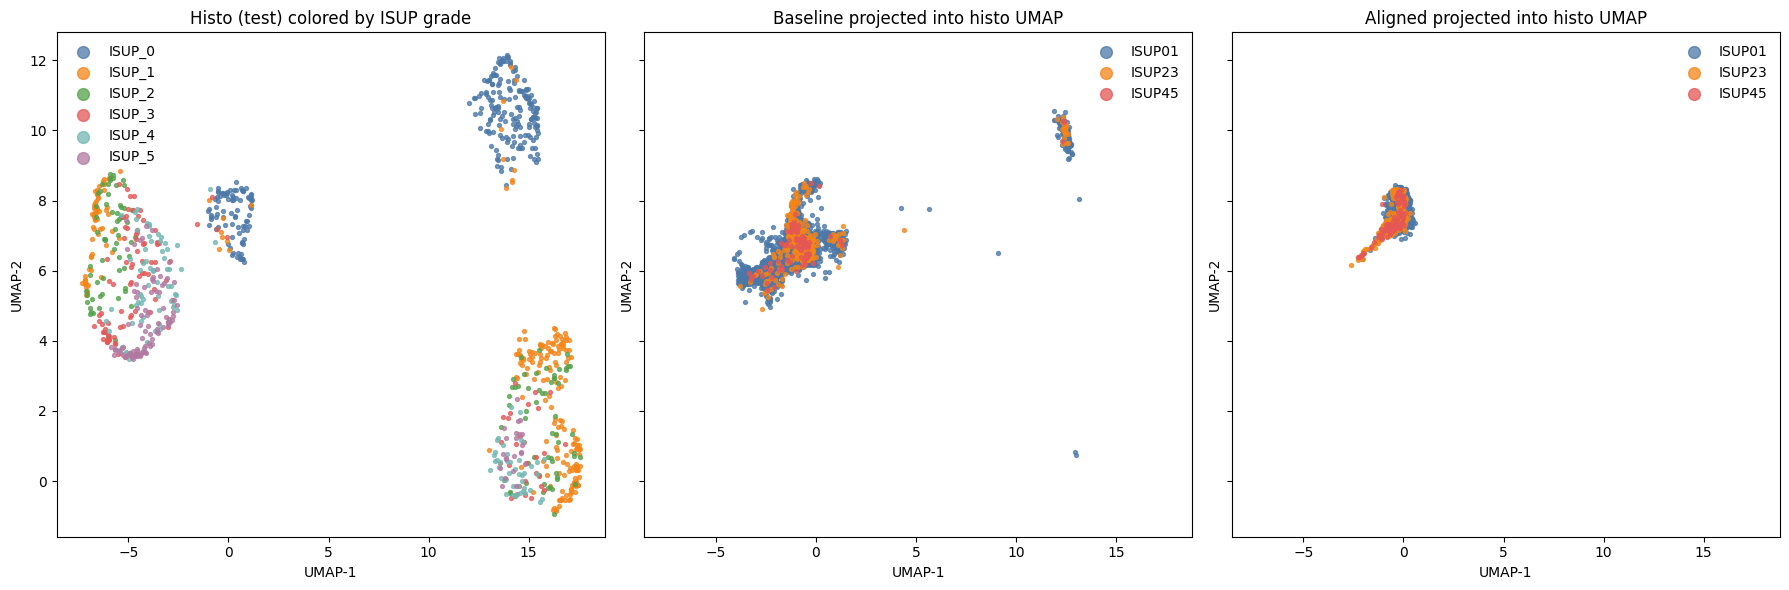

In [7]:
def scatter_by_label(ax, X2, y, title, palette, label_names, s=8, alpha=0.75, fallback_color="#808080"):
    if y is None:
        ax.scatter(X2[:, 0], X2[:, 1], s=s, alpha=alpha, c=fallback_color)
        ax.set_title(title + " (unlabeled)")
        ax.set_xlabel("UMAP-1")
        ax.set_ylabel("UMAP-2")
        return

    y = np.asarray(y)
    valid = ~pd.isna(y)

    y_float = np.full(y.shape, np.nan, dtype=float)
    y_float[valid] = y[valid].astype(float)

    for k in sorted(pd.unique(pd.Series(y[valid]).astype(int))):
        m = valid & (y_float == float(k))
        ax.scatter(
            X2[m, 0],
            X2[m, 1],
            s=s,
            alpha=alpha,
            label=label_names.get(int(k), str(k)),
            c=palette.get(int(k), fallback_color),
        )

    if (~valid).any():
        ax.scatter(X2[~valid, 0], X2[~valid, 1], s=s, alpha=0.25, c=fallback_color, label="unlabeled")

    ax.set_title(title)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(markerscale=3, frameon=False, loc="best")


# Shared axis limits so visual comparison is fair
all_xy = np.vstack([H2, A2, B2])
xmin, ymin = all_xy.min(axis=0)
xmax, ymax = all_xy.max(axis=0)
pad_x = 0.05 * (xmax - xmin + 1e-8)
pad_y = 0.05 * (ymax - ymin + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

scatter_by_label(axes[0], H2, yH, f"Histo ({SET}) colored by ISUP grade", histo_palette, histo_label_names, s=S_HISTO, alpha=ALPHA)
scatter_by_label(axes[1], A2, yA, f"{NAME_A} projected into histo UMAP", mri_palette, mri_label_names, s=S_MRI, alpha=ALPHA)
scatter_by_label(axes[2], B2, yB, f"{NAME_B} projected into histo UMAP", mri_palette, mri_label_names, s=S_MRI, alpha=ALPHA)

for ax in axes:
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

plt.tight_layout()
plt.show()


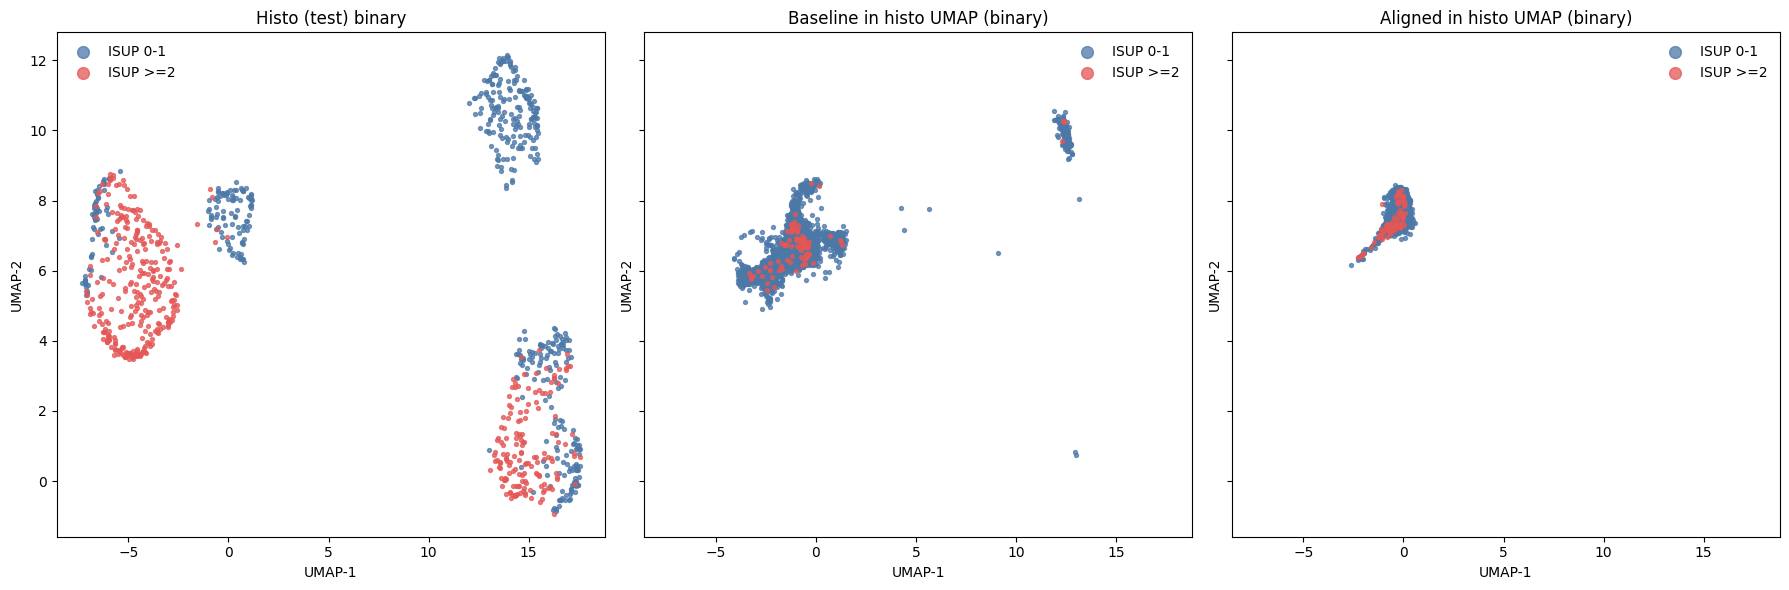

In [8]:
# --- Optional: cancer vs non-cancer view (binary coloring) ---
def to_binary_cs(arr):
    if arr is None:
        return None
    arr = np.asarray(arr)
    out = np.full(arr.shape, np.nan, dtype=float)
    valid = ~pd.isna(arr)
    out[valid] = (arr[valid].astype(float) >= 2).astype(float)
    return out

bin_palette = {0: "#4C78A8", 1: "#E45756"}
bin_names = {0: "ISUP 0-1", 1: "ISUP >=2"}

yH_bin = to_binary_cs(yH)
yA_bin = to_binary_cs(yA)
yB_bin = to_binary_cs(yB)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)
scatter_by_label(axes[0], H2, yH_bin, f"Histo ({SET}) binary", bin_palette, bin_names, s=S_HISTO, alpha=ALPHA)
scatter_by_label(axes[1], A2, yA_bin, f"{NAME_A} in histo UMAP (binary)", bin_palette, bin_names, s=S_MRI, alpha=ALPHA)
scatter_by_label(axes[2], B2, yB_bin, f"{NAME_B} in histo UMAP (binary)", bin_palette, bin_names, s=S_MRI, alpha=ALPHA)

for ax in axes:
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

plt.tight_layout()
plt.show()


In [9]:
# # --- Optional: save the projected coordinates for later analysis ---
# save_dir = "./umap_outputs"
# os.makedirs(save_dir, exist_ok=True)

# pd.DataFrame({
#     "umap1": H2[:, 0],
#     "umap2": H2[:, 1],
#     "label": yH if yH is not None else np.nan,
#     "id": metaH["id"],
# }).to_csv(os.path.join(save_dir, f"histo_{SET}_projected.csv"), index=False)

# pd.DataFrame({
#     "umap1": A2[:, 0],
#     "umap2": A2[:, 1],
#     "label": yA,
# }).to_csv(os.path.join(save_dir, f"mri_{SET}_{NAME_A.lower().replace(' ', '_')}_in_histo_umap.csv"), index=False)

# pd.DataFrame({
#     "umap1": B2[:, 0],
#     "umap2": B2[:, 1],
#     "label": yB,
# }).to_csv(os.path.join(save_dir, f"mri_{SET}_{NAME_B.lower().replace(' ', '_')}_in_histo_umap.csv"), index=False)

# summary.to_csv(os.path.join(save_dir, f"silhouette_summary_{SET}.csv"), index=False)

# print(f"Saved outputs to: {os.path.abspath(save_dir)}")


## How to interpret this

- **Histo panel:** this is the reference UMAP, colored by the full **6-class ISUP grade (0-5)** from the histopathology split CSV.
- **MRI panels:** these are not separate UMAPs. They are the baseline and aligned MRI embeddings transformed into the **same histopathology-defined 2D space**.
- **Good sign:** the aligned MRI points land in regions of the histopathology UMAP that roughly respect the same broad disease progression, and look more class-organized than the baseline projection.
- **Important caution:** because MRI is still labeled in **3 classes** while histopathology is shown in **6 classes**, the MRI plots will usually look coarser and more spread out than the histo plot even when the alignment is working.
- **Less useful sign:** if you fit separate UMAPs for each space, UMAP can rotate / stretch / fragment them differently, so side-by-side plots become hard to compare.

A cleaner story usually comes from combining this visualization with quantitative checks such as:
- k-nearest-neighbor label agreement in histo space,
- cross-modal retrieval by class,
- silhouette score in the histo-fitted preprocessed feature space,
- centroid distance or Maximum Mean Discrepancy between same-class MRI and histo embeddings.
